<a href="https://colab.research.google.com/github/GabyVothy/Text-Classification/blob/main/Topic_model_analysis_optimized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## I. BACKGROUND OF PROJECT

<span style="color: #1E3A8A; font-size: 14px;">
<strong>Goal of this project </strong>  is to use topic model to extract information from user review on Nike’s products, giving business insight to address room/area for improvement. <br>
<strong>The Business Objective </strong> is to identify potential area to improve, via user's feedback - identify the most satisfied/complaint topic about company's product/pricing/servicing/ect. <br>
<strong>The data pipeline </strong> we will build by combining Product-Item ID (aka ASIN or more commonly SKU) and and corresponding reviews, word vectorizing by TF-IDF method and NMF model for topic building. <br>
<strong> Evaluation, conclusion and future work </strong> is to identify the proper meaning that topic represent, and come up with possible actions to improve the shortcomings.
</span>


## II. DATA PREPARATION & MODEL BUIDLING WITH TOPIC CLASSIFICATION


## 1. Category Statistics and Review Mapping

In [1]:
import json
import pandas as pd
from collections import Counter
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

#Please update these paths to match where your files are stored
base_path = '/content/drive/MyDrive/'
meta_path = base_path + 'meta_Clothing_Shoes_and_Jewelry.jsonl'
reviews_path = base_path + 'reviews_Clothing_Shoes_and_Jewelry.json'

#Map ASIN to categories and title
nike_asin_to_categories = {}
asin_to_title = {}
category_product_counts = Counter()

#as the data is huge, I choose to open without import to save the memory
with open(meta_path, 'rt', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        asin = data.get('asin')
        if not asin:
            continue
        asin_to_title[asin] = data.get('title', 'Unknown Product')

        categories = [c.lower().strip() for cat_list in data.get('categories', []) for c in cat_list]
        if 'nike' in categories:
            # Exclude generic brand tags from category statistics
            sub_categories = [c for c in set(categories) if c not in ['clothing, shoes & jewelry', 'nike', 'shoes']]
            nike_asin_to_categories[asin] = sub_categories if sub_categories else ['uncategorized']
            for cat in nike_asin_to_categories[asin]:
                category_product_counts[cat] += 1

#Map reviews to categories via ASIN
category_review_counts = Counter()
total_nike_reviews = 0
reviews_list = []

with open(reviews_path, 'rt', encoding='utf-8') as f:
    for line in f:
        review = json.loads(line)
        asin = review.get('asin')
        if asin in nike_asin_to_categories:
            total_nike_reviews += 1
            review_text = ((review.get('summary') or '') + ' ' + (review.get('reviewText') or '')).strip()
            reviews_list.append({
                'asin': asin,
                'reviewText': review_text,
                'overall': review.get('overall'),
                'unixReviewTime': review.get('unixReviewTime'), #--including time for later analysis on timeline
                'reviewTime': review.get('reviewTime')
            })
            for cat in nike_asin_to_categories[asin]:
                category_review_counts[cat] += 1

#Convert to DataFrame for summary statistics
df_category_stats = pd.DataFrame([
    {
        'Category': cat,
        'Product_Count': category_product_counts[cat],
        'Review_Count': count,
        'Reviews_Per_Product': round(count / category_product_counts[cat], 2)
    }
    for cat, count in category_review_counts.most_common(15)
])

print(f'Total Nike ASINs: {len(nike_asin_to_categories)}')
print(f'Total Nike Reviews: {total_nike_reviews}')
print('\nTop Categories by Review Volume:')
print(df_category_stats.to_string(index=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total Nike ASINs: 8327
Total Nike Reviews: 21570

Top Categories by Review Volume:
                Category  Product_Count  Review_Count  Reviews_Per_Product
                       n           8327         21570                 2.59
                     men           4996         13431                 2.69
                athletic           5153         13132                 2.55
                 running           3031          8589                 2.83
                   women           2382          6194                 2.60
       sports & outdoors            996          2836                 2.85
        fashion sneakers           1113          2703                 2.43
              basketball           1067          2189                 2.05
                clothing            707          1829                 2.59
                 sandals            17

## 2. Word Processing

In [2]:
#Check distribution of review per ASIN
asin_category_counts = [
    {'asin': asin, 'category_count': len(categories), 'categories': categories}
    for asin, categories in nike_asin_to_categories.items()
]
df_asin_counts = pd.DataFrame(asin_category_counts)

print('Distribution of category counts per ASIN:')
print(df_asin_counts['category_count'].value_counts().sort_index())


# Check if there are certain ASINs classified into the most categories
pd.set_option('display.max_colwidth', None)
print('\nASINs with the highest number of categories:')
print(df_asin_counts.sort_values(by='category_count', ascending=False).head())

Distribution of category counts per ASIN:
category_count
1      247
2      168
3     1207
4     4491
5      943
6      255
7      365
8      292
9      101
10     152
11      84
12      19
13       3
Name: count, dtype: int64

ASINs with the highest number of categories:
            asin  category_count  \
5749  B009PFMF7C              13   
7685  B00FEM0LG2              13   
177   B000E8H0LA              13   
206   B000E8J5PY              12   
237   B000EHIVA0              12   

                                                                                                                                                                                                                   categories  
5749                                                                           [sports & outdoors, women, running, tank tops, n, clothing, active, men, shirts, petite, active shirts & tees, big & tall, exercise & fitness]  
7685                                              [sports & out

### having certain understanding on data structure, now we proceed to word processing with removal common words, use WordNetLemmatizer  to convert various tense of the words into origin form, so the model later can do better job in measuring the frequency of word for topic grouping task.

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


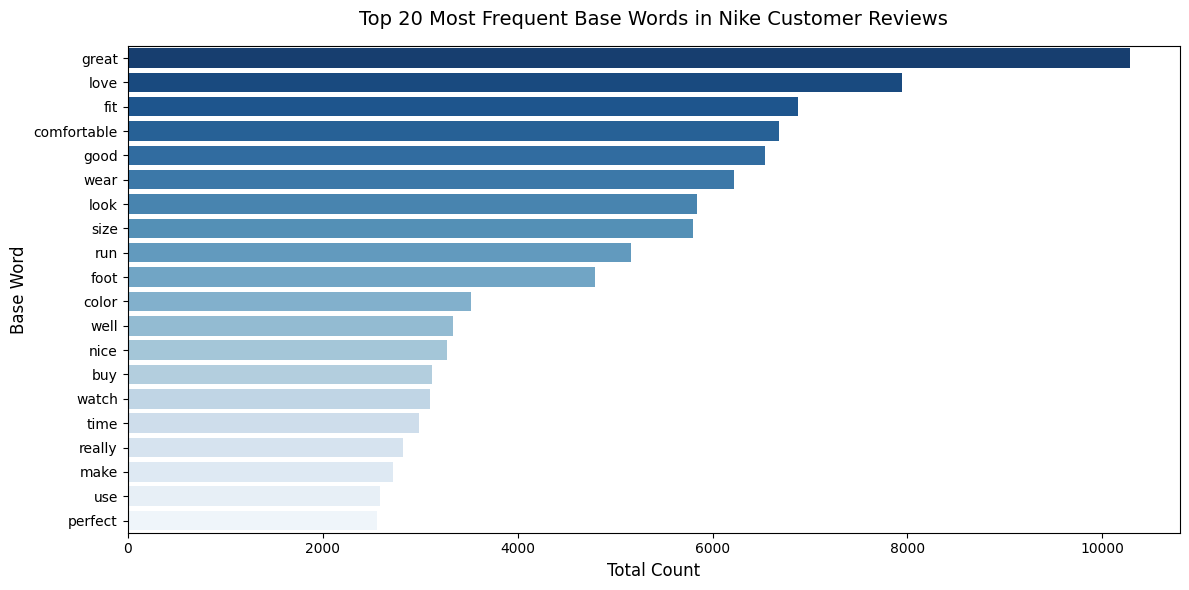

In [3]:
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')  # Needed for POS tagging
nltk.download('omw-1.4')                     # Recommended for WordNet

df_reviews = pd.DataFrame(reviews_list)

stop_words = set(stopwords.words('english'))
stop_words.update(['nike', 'shoe', 'shoes', 'pair', 'bought', 'got', 'get', 'one', 'like', 'would'])
lemmatizer = WordNetLemmatizer()
clean_pattern = re.compile(r'[^a-zA-Z\s]')
POS_MAP = {'J': wordnet.ADJ, 'V': wordnet.VERB, 'N': wordnet.NOUN, 'R': wordnet.ADV}

def preprocess_tokens(tokens, pos_tags):
    clean_tokens = []
    for word, tag in pos_tags:
        if word not in stop_words and len(word) > 2:
            lemma = lemmatizer.lemmatize(word, pos=POS_MAP.get(tag[0], wordnet.NOUN))
            clean_tokens.append(lemma)
    return ' '.join(clean_tokens)

#tokenize all reviews & POS tagging
all_tokens = [clean_pattern.sub('', str(t).lower()).split() for t in df_reviews['reviewText']]
all_pos_tags = nltk.pos_tag_sents(all_tokens)
df_reviews['clean_text'] = [preprocess_tokens(toks, tags) for toks, tags in zip(all_tokens, all_pos_tags)]

#Vectorize to count word frequencies
cv = CountVectorizer(max_df=0.95, min_df=5)
dtm = cv.fit_transform(df_reviews['clean_text'])
word_counts = dtm.sum(axis=0).A1
vocab = cv.get_feature_names_out()

df_words = pd.DataFrame({'word': vocab, 'count': word_counts}).sort_values(by='count', ascending=False).head(20)

# Plot top 20 words
plt.figure(figsize=(12, 6))
sns.barplot(data=df_words, x='count', y='word', hue='word', legend=False, palette='Blues_r')
plt.title('Top 20 Most Frequent Base Words in Nike Customer Reviews', fontsize=14, pad=15)
plt.xlabel('Total Count', fontsize=12)
plt.ylabel('Base Word', fontsize=12)
plt.tight_layout()
plt.show()

REMARK: The top 20 frequent words across all reviews suggest an overall positive impression. Let's also break this down by top category to see how sentiment varies.

## 3. Build Topic Model using NMF

In [4]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# Vectorize text using TF-IDF
tfidf_vect = TfidfVectorizer(max_df=0.95, min_df=5, stop_words='english')
dtm_tfidf = tfidf_vect.fit_transform(df_reviews['clean_text'])

# Fit NMF & get the document-topic matrix --initiated with 50 topics
NUM_TOPICS = 50
nmf_model = NMF(n_components=NUM_TOPICS, random_state=42, init='nndsvd')
doc_topic_matrix = nmf_model.fit_transform(dtm_tfidf)

# format topics into a 3-column table format
def display_topics_table(model, feature_names, no_top_words, num_cols=3):
    topic_strings = []
    for topic_idx, topic in enumerate(model.components_):
        top_words = ' '.join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]])
        topic_strings.append(f'{topic_idx}: {top_words}')

    while len(topic_strings) % num_cols != 0:
        topic_strings.append('')

    grid = np.array(topic_strings).reshape(-1, num_cols, order='F')
    return pd.DataFrame(grid)

#Display the results showing 5 words per topic
df_topics = display_topics_table(nmf_model, tfidf_vect.get_feature_names_out(), no_top_words=5, num_cols=3)
display(df_topics.style.hide(axis='index').hide(axis='columns'))

0: great service workout value fast,17: wear day everyday ive normally,34: time long arrive come new
1: size true large half big,18: perfect condition thank gym arrive,35: work day hour stand long
2: star reason excellent narrow rating,19: buy dont definitely store money,36: awesome cool cleat worth jordan
3: love daughter absolutely husband boyfriend,20: really like cool enjoy pretty,37: gift christmas birthday grandson friend
4: good pretty far quality value,21: little big think bit snug,38: quality excellent high material poor
5: watch band wrist easy battery,22: son like school basketball christmas,39: support arch need ankle high
6: year old new school ive,23: light weight super flexible easy,40: sandal slide comfort summer strap
7: sock dry wash crew drifit,24: order receive large item amazon,41: want exactly dont know picture
8: nice design confortable shirt kick,25: happy daughter wife thank new,42: purchase amazon satisfied glad store
9: fit perfectly true glove right,26: price worth store pay reasonable,43: bag gym carry pocket clothes
10: comfy super cute stylish definitely,27: air max force jordan pegasus,44: say husband like come thank


## 4. Visualize Topics

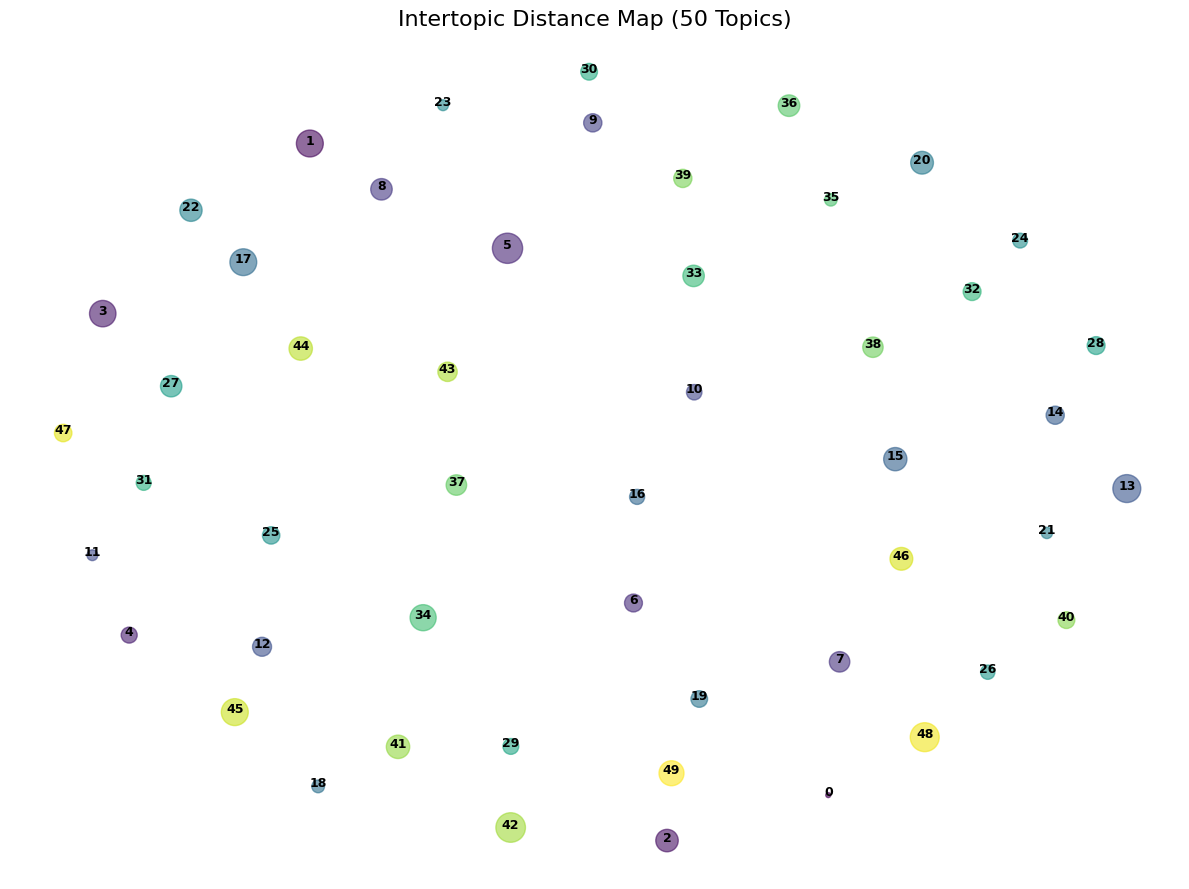

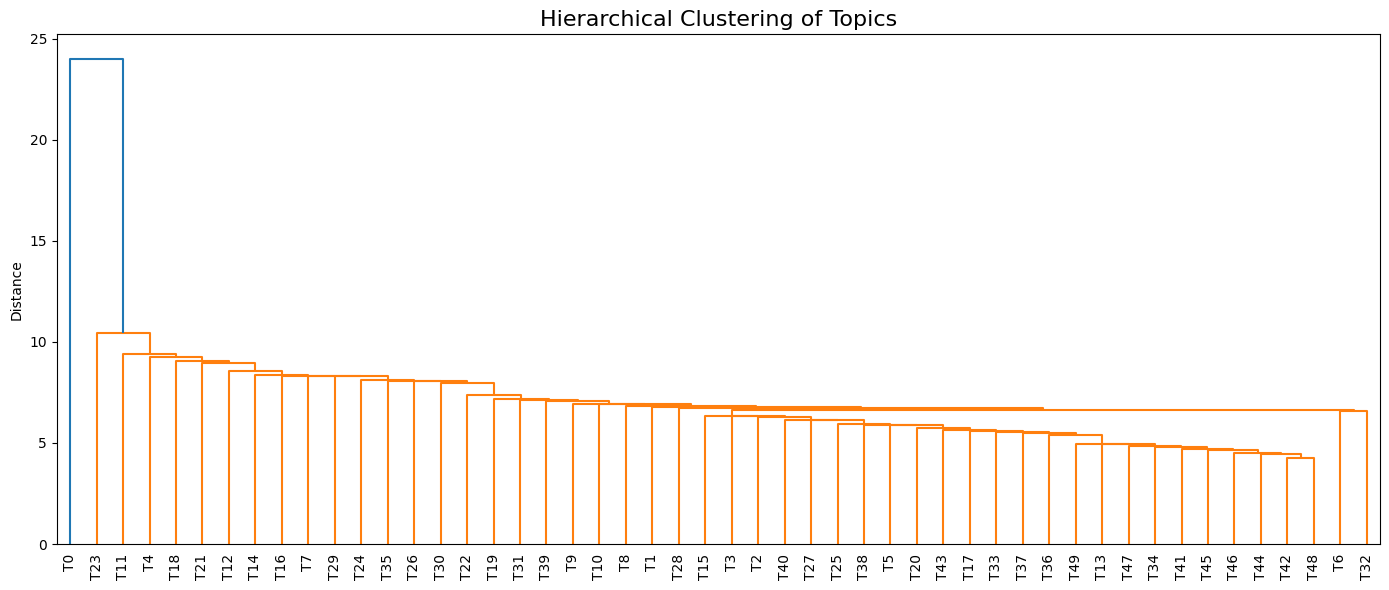

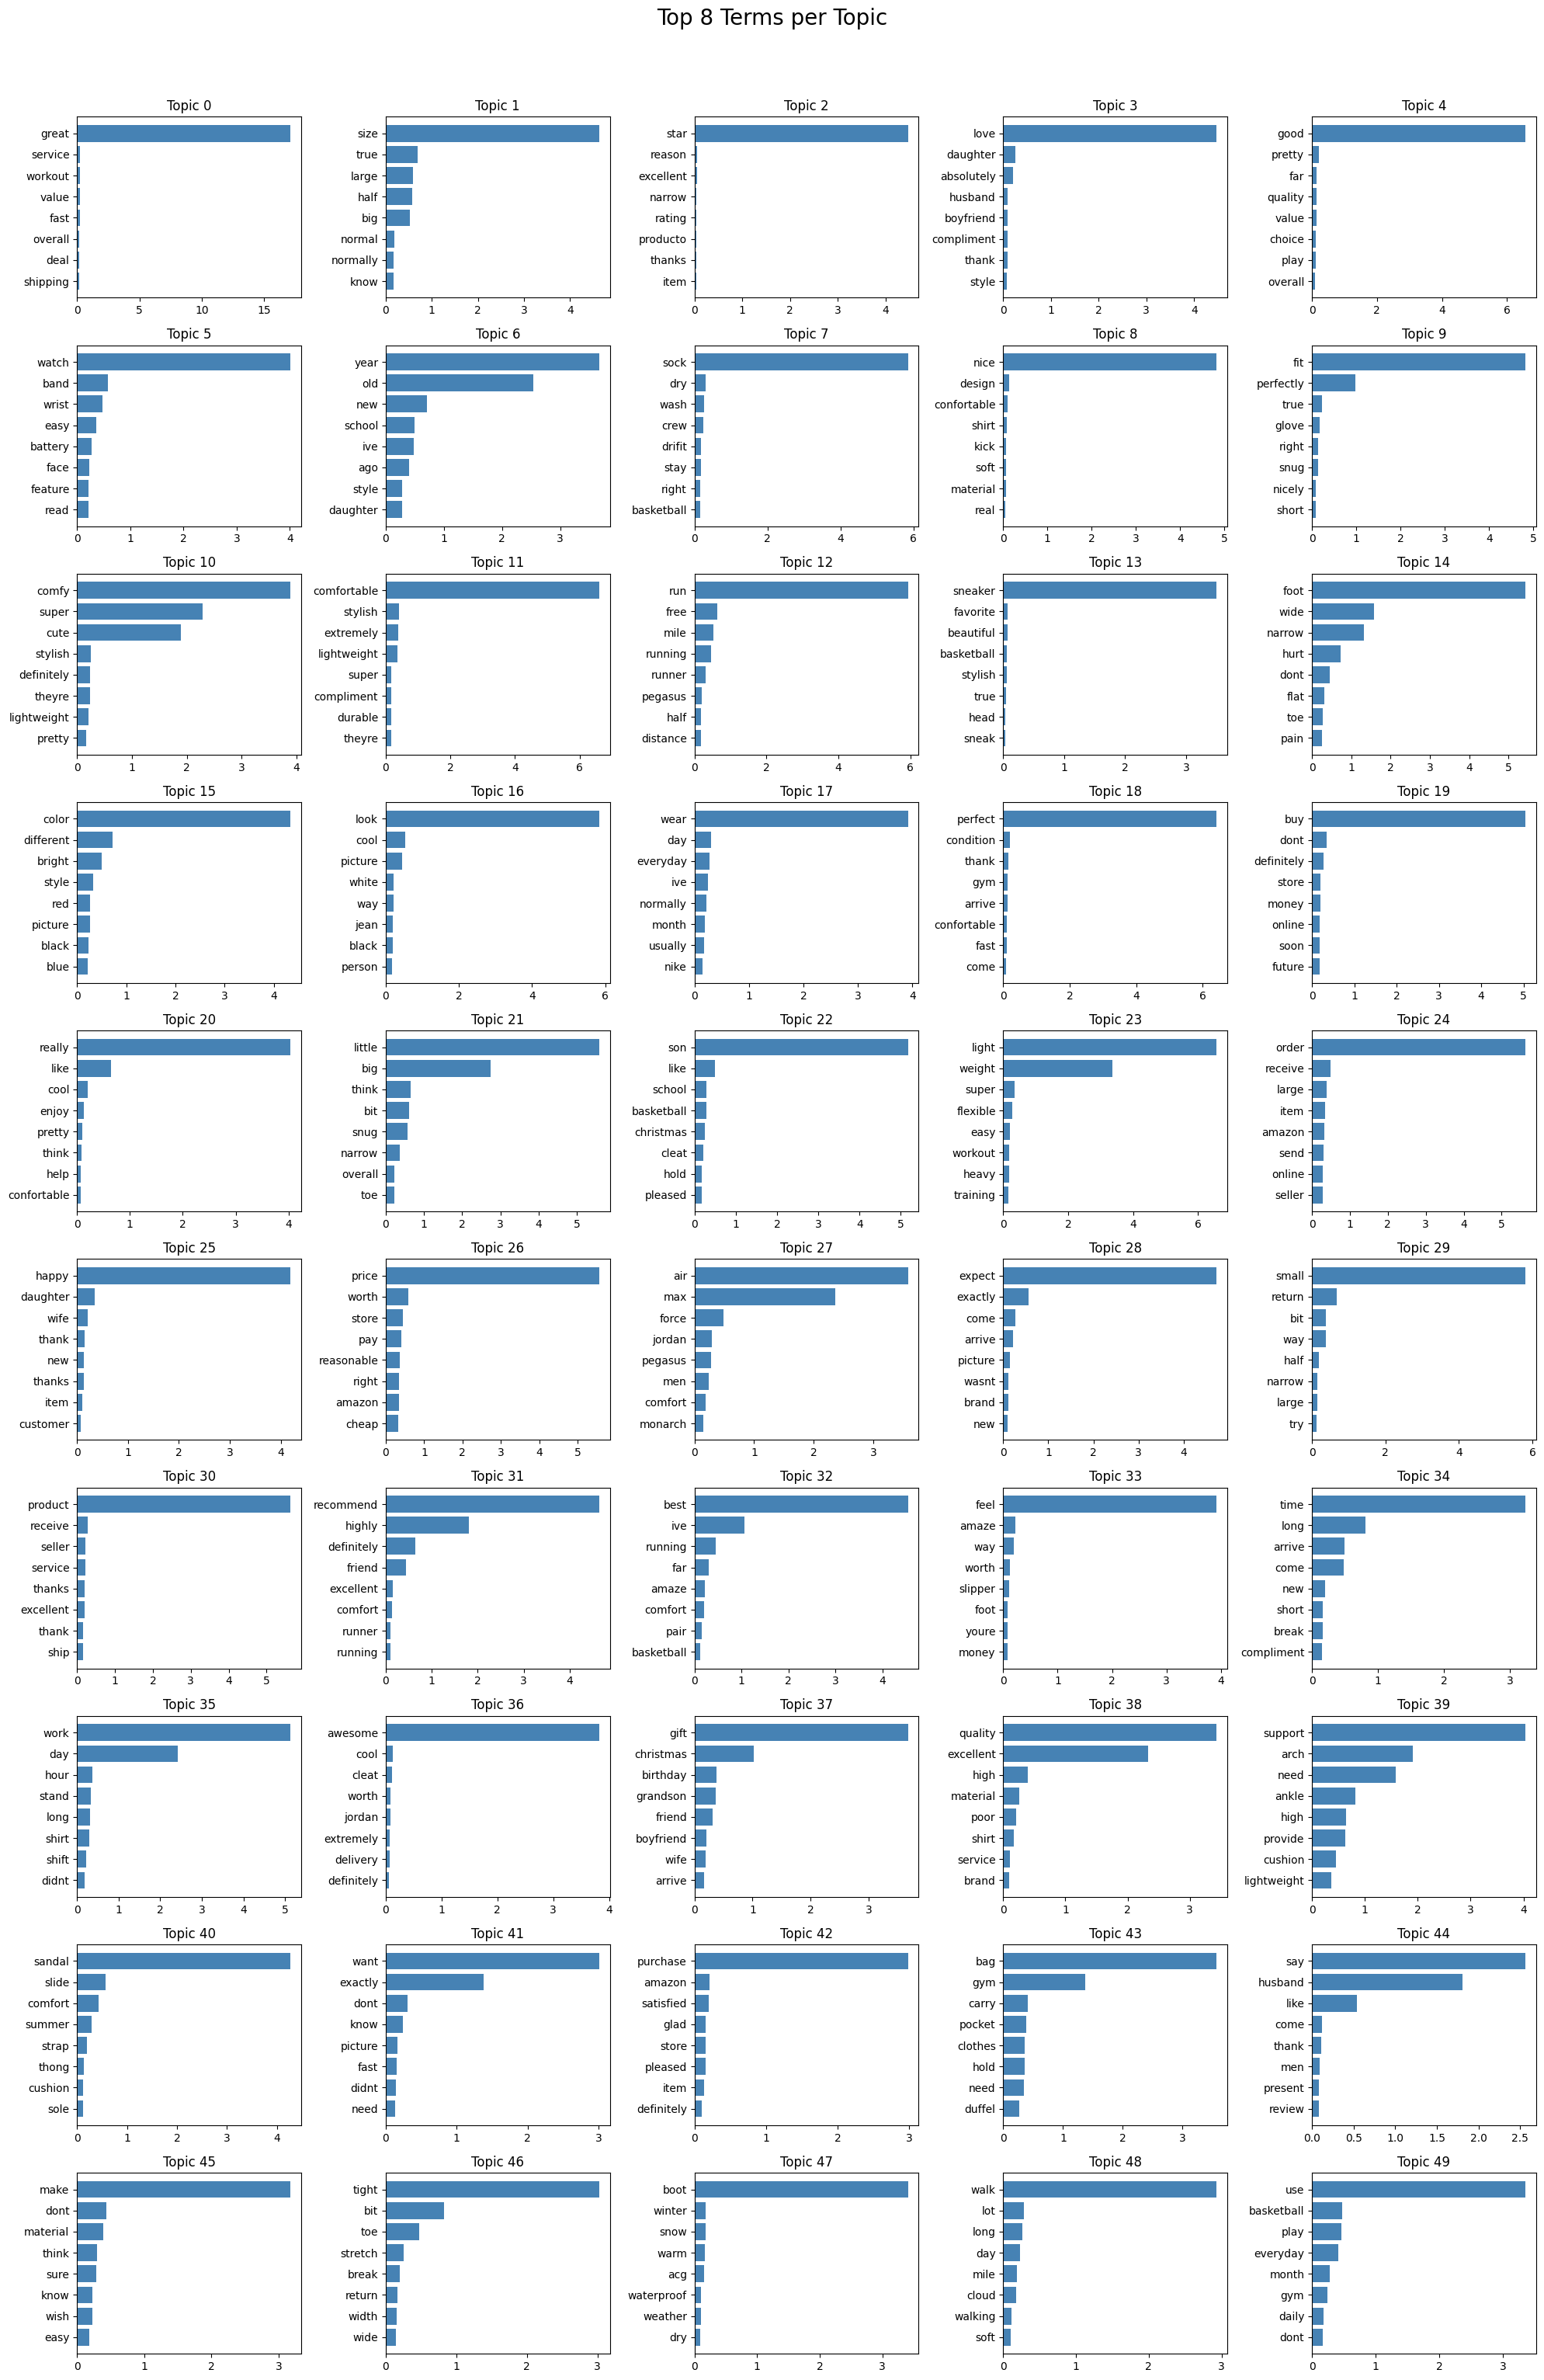

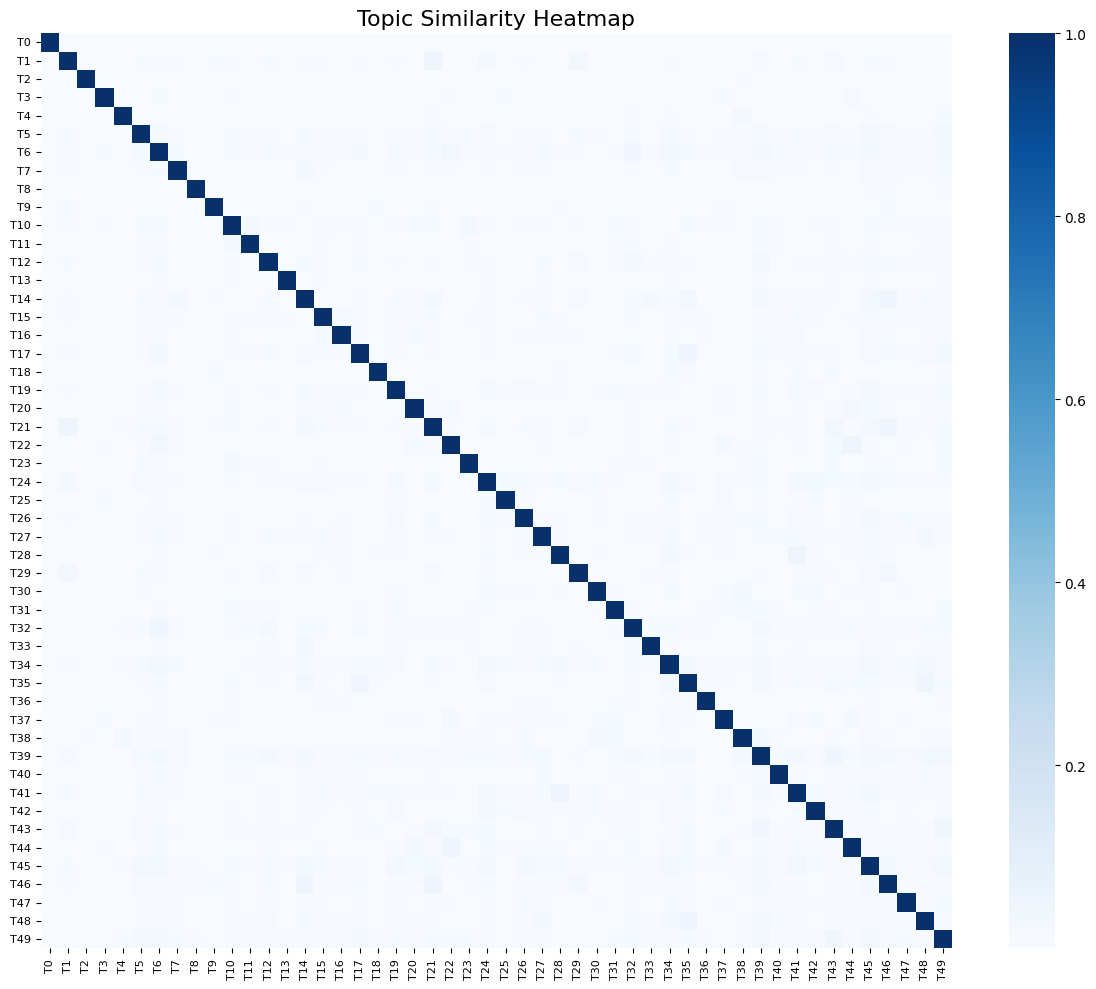

In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from sklearn.manifold import MDS
from scipy.cluster.hierarchy import linkage, dendrogram

# Assign the dominant topic (highest score) to each review
df_reviews['dominant_topic'] = np.argmax(doc_topic_matrix, axis=1)

# Extract the topic-term matrix
topic_term_matrix = nmf_model.components_
feature_names = tfidf_vect.get_feature_names_out()

# Safely calculate topic sizes (ensuring all 50 topics are counted, even if 0)
topic_counts = df_reviews['dominant_topic'].value_counts()
topic_sizes = np.array([topic_counts.get(i, 0) for i in range(NUM_TOPICS)])

# Distant map
plt.figure(figsize=(12, 9))
distances = cosine_distances(topic_term_matrix)
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
topic_coordinates = mds.fit_transform(distances)

plt.scatter(topic_coordinates[:, 0], topic_coordinates[:, 1],
            s=topic_sizes * 0.5, alpha=0.6, c=range(NUM_TOPICS), cmap='viridis')

for i in range(NUM_TOPICS):
    plt.annotate(f'{i}', (topic_coordinates[i, 0], topic_coordinates[i, 1]),
                 fontsize=9, fontweight='bold', ha='center')

plt.title(f'Intertopic Distance Map ({NUM_TOPICS} Topics)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# Dendogram
plt.figure(figsize=(14, 6))
Z = linkage(topic_term_matrix, method='ward')

dendrogram(Z, labels=[f'T{i}' for i in range(NUM_TOPICS)],
           leaf_rotation=90, leaf_font_size=10)

plt.title('Hierarchical Clustering of Topics', fontsize=16)
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

#Dynamic grid
n_top_words = 8
cols = 5
rows = math.ceil(NUM_TOPICS / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 3 * rows))
axes = axes.flatten()

for topic_idx, topic in enumerate(topic_term_matrix):
    top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
    top_features = [feature_names[i] for i in top_features_ind]
    weights = topic[top_features_ind]

    ax = axes[topic_idx]
    ax.barh(top_features, weights, color='steelblue')
    ax.set_title(f'Topic {topic_idx}', fontdict={'fontsize': 12})
    ax.invert_yaxis()

for i in range(NUM_TOPICS, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(f'Top {n_top_words} Terms per Topic', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

#Cosin Similarity
plt.figure(figsize=(12, 10))
similarity_matrix = cosine_similarity(topic_term_matrix)

sns.heatmap(similarity_matrix,
            annot=False,
            cmap='Blues',
            xticklabels=[f'T{i}' for i in range(NUM_TOPICS)],
            yticklabels=[f'T{i}' for i in range(NUM_TOPICS)])

plt.title('Topic Similarity Heatmap', fontsize=16)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
#Inspect review vs. topic dominant from model grouping
df_reviews['product_title'] = df_reviews['asin'].map(asin_to_title)

feature_names = tfidf_vect.get_feature_names_out()
topics_to_inspect = [1, 33, 42]

for topic in topics_to_inspect:
    topic_weights = nmf_model.components_[topic]
    top_word_indices = topic_weights.argsort()[:-6:-1]
    top_5_words = [feature_names[i] for i in top_word_indices]
    top_words_str = ', '.join(top_5_words)

    print(f"\n{'='*80}")
    print(f'TOPIC {topic} | Top Words: [{top_words_str}]')
    print(f"{'='*80}")

    sample_reviews = df_reviews[df_reviews['dominant_topic'] == topic].head(12)

    for _, row in sample_reviews.iterrows():
        print(f"ASIN: {row['asin']} | Product: {row['product_title']}")
        print(f"Review: {row['reviewText']}\n{'-'*80}")


TOPIC 1 | Top Words: [size, true, large, half, big]
ASIN: B0002164KC | Product: Nike Talaria 365
Review: Unmatchable. By far, the best pair of shoes I've ever owned. Well, you only need to know that their size is normally smaller than normal. You may need to order them bigger in size than you would normally do, e.g, your size is 12, get them 12.5. Anyways, I've been trying to shop for them Worldwide, but I failed to find them. I'd love to buy them in all colors!
--------------------------------------------------------------------------------
ASIN: B0006NGUE6 | Product: Nike Men's Air Rival Golf Shoes (Medium) (11 D(M), White/Khaki/Medium Brown)
Review: Great Golf Shoes After finally learning that Nike shoes are always smaller than the listed size, I ordered 1/2 size larger than normal.  They are the most como9frtable golf shoes I have ever owned!!
--------------------------------------------------------------------------------
ASIN: B0006NGUE6 | Product: Nike Men's Air Rival Golf Shoe

### we started with 50 but it looks too much and cause difficulty by giving intuitive impression, thus I will run coherent analysis to see which is optimal number of topics to group

K=5: coherence = 0.5113
K=10: coherence = 0.5137
K=15: coherence = 0.5251
K=20: coherence = 0.5271
K=30: coherence = 0.5314
K=50: coherence = 0.4981


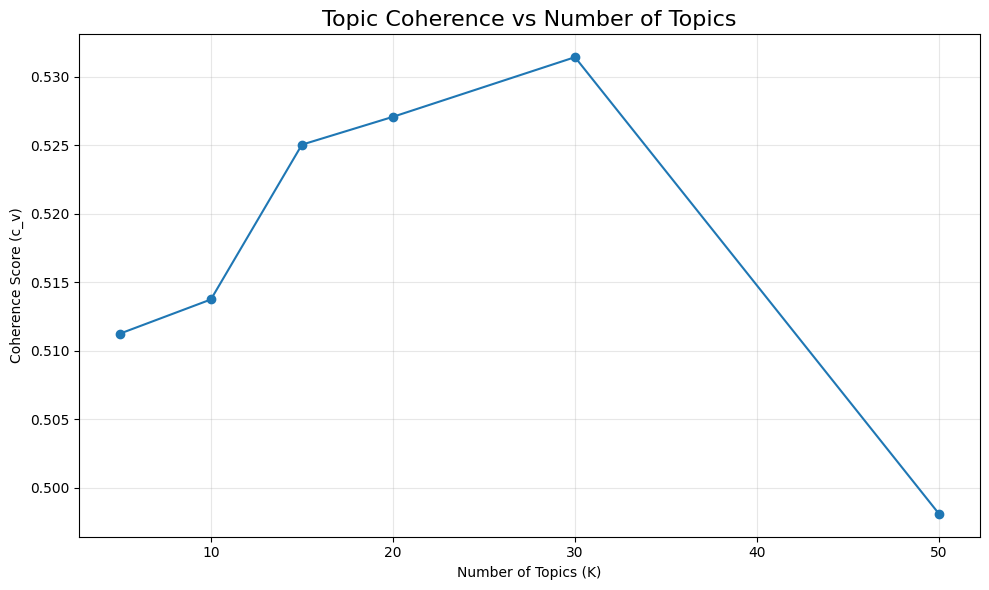


Best K by coherence: 30


In [7]:
# Finding Nemo, what is best number of topic we should set?
import warnings
warnings.simplefilter("ignore", category=UserWarning)

!pip install gensim --break-system-packages
import sys, os, contextlib
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from sklearn.decomposition import NMF

!pip install --upgrade requests urllib3 charset-normalizer

#Set up dictionary from the text we cleaned earlier
texts = [t.split() for t in df_reviews['clean_text']]
dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(t) for t in texts]
feature_names = tfidf_vect.get_feature_names_out()

# Fit NMF at several topic counts and score coherence for each
topic_range = [5, 10, 15, 20, 30, 50]
coherence_results = []

for k in topic_range:
    model = NMF(n_components=k, random_state=42, init='nndsvd')
    model.fit(dtm_tfidf)

    topics = [[feature_names[i] for i in topic.argsort()[:-11:-1]] for topic in model.components_]
    cm = CoherenceModel(topics=topics, texts=texts, dictionary=dictionary, coherence='c_v')
    score = cm.get_coherence()

    coherence_results.append({'num_topics': k, 'coherence': score})
    print(f'K={k}: coherence = {score:.4f}')

#Plot coherence vs number of topics to spot the best K
df_coherence = pd.DataFrame(coherence_results)

plt.figure(figsize=(10, 6))
plt.plot(df_coherence['num_topics'], df_coherence['coherence'], marker='o')
plt.title('Topic Coherence vs Number of Topics', fontsize=16)
plt.xlabel('Number of Topics (K)')
plt.ylabel('Coherence Score (c_v)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_k = df_coherence.loc[df_coherence['coherence'].idxmax(), 'num_topics']
print(f'\nBest K by coherence: {best_k}')

### from data above, we can see optimal number of topic is 30, however it's not far from 15,  thus for more intuition in information review let's use 15 topics:

In [8]:
# Fit NMF to 15 topics
NUM_TOPICS = 15
nmf_model2 = NMF(n_components=NUM_TOPICS, random_state=42, init='nndsvd')
doc_topic_matrix2 = nmf_model2.fit_transform(dtm_tfidf)

df_topics2 = display_topics_table(nmf_model2, tfidf_vect.get_feature_names_out(), no_top_words=5, num_cols=3)
display(df_topics2.style.hide(axis='index').hide(axis='columns'))

0: great look price feel buy,5: watch band wrist time easy,10: foot wear day feel work
1: size small order big large,6: run light use small free,11: comfortable light recommend color walk
2: star awesome reason excellent narrow,7: sock wear dry quality wash,12: son happy say gift purchase
3: love color husband daughter absolutely,8: nice look really color cool,13: sneaker air look max purchase
4: good price look quality really,9: fit perfect expect perfectly color,14: product excellent quality recommend expect


from a quick look, we can identify quite a few impression here: good price, potentiall issue on size, nice design/color, sock quality concern, happy with delivery and services.
Let's see how is distribution of the topics:

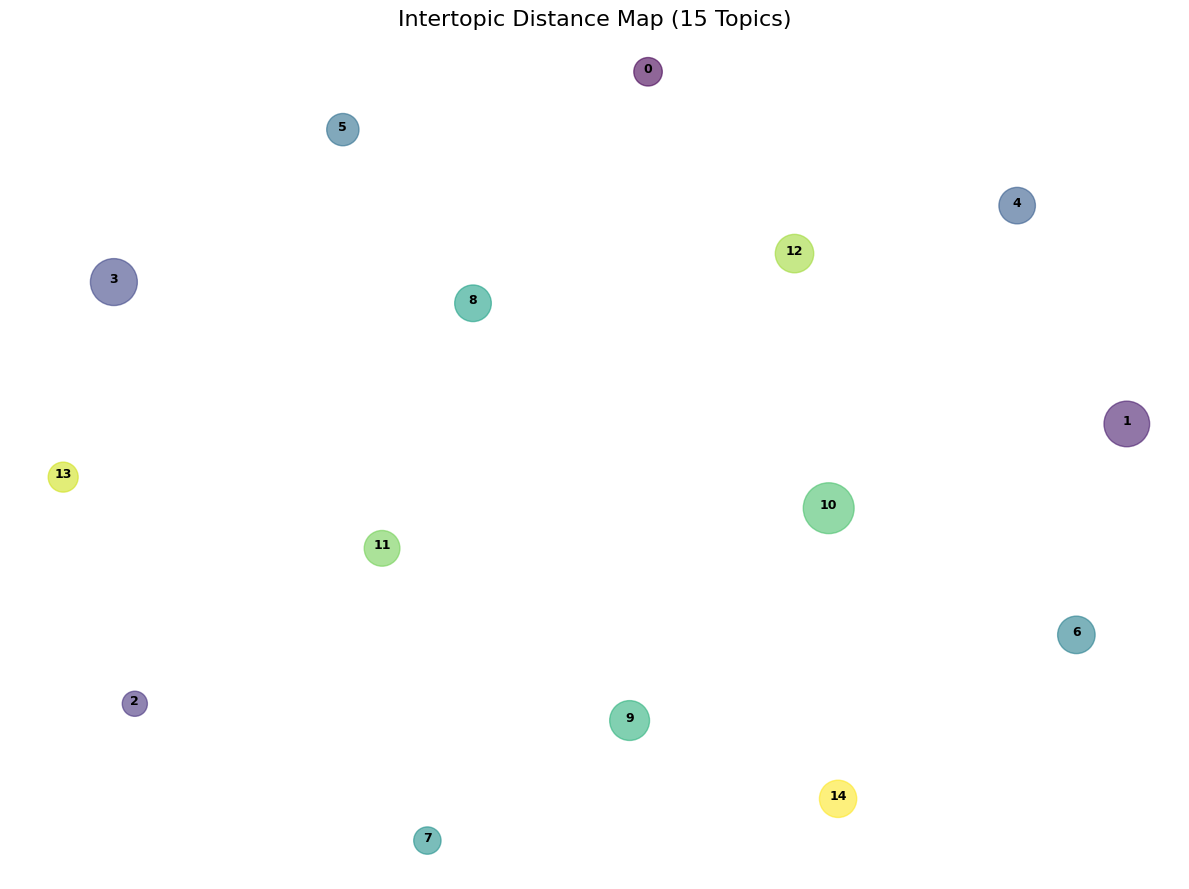

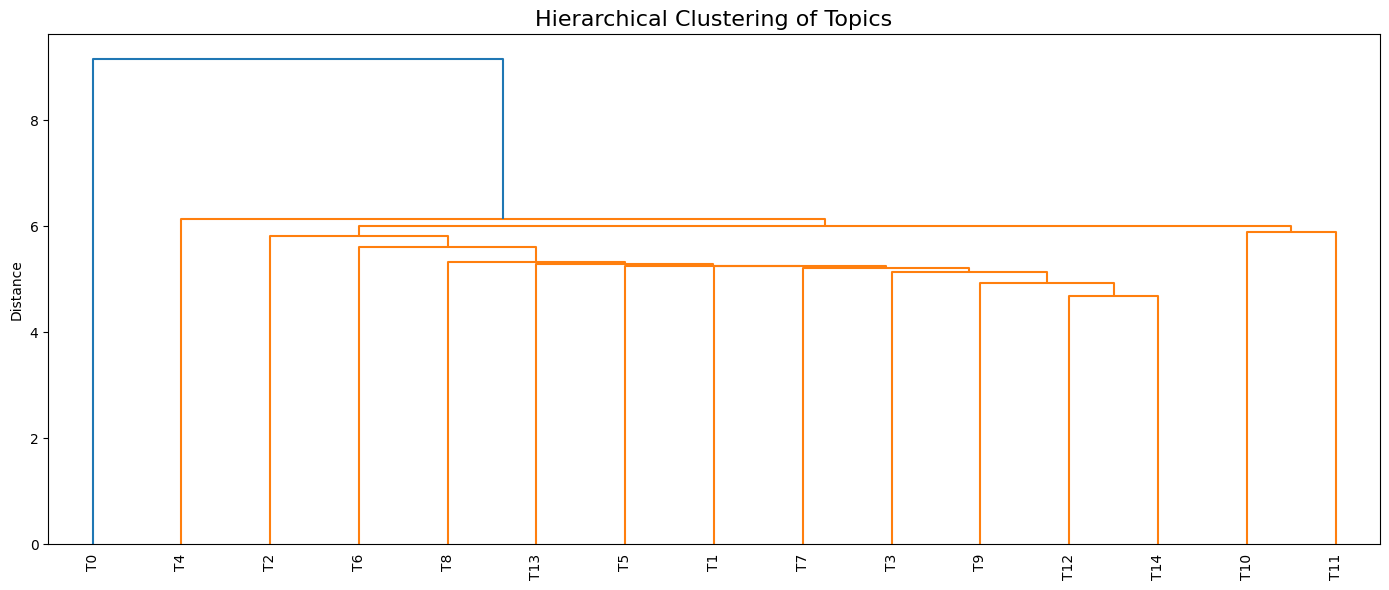

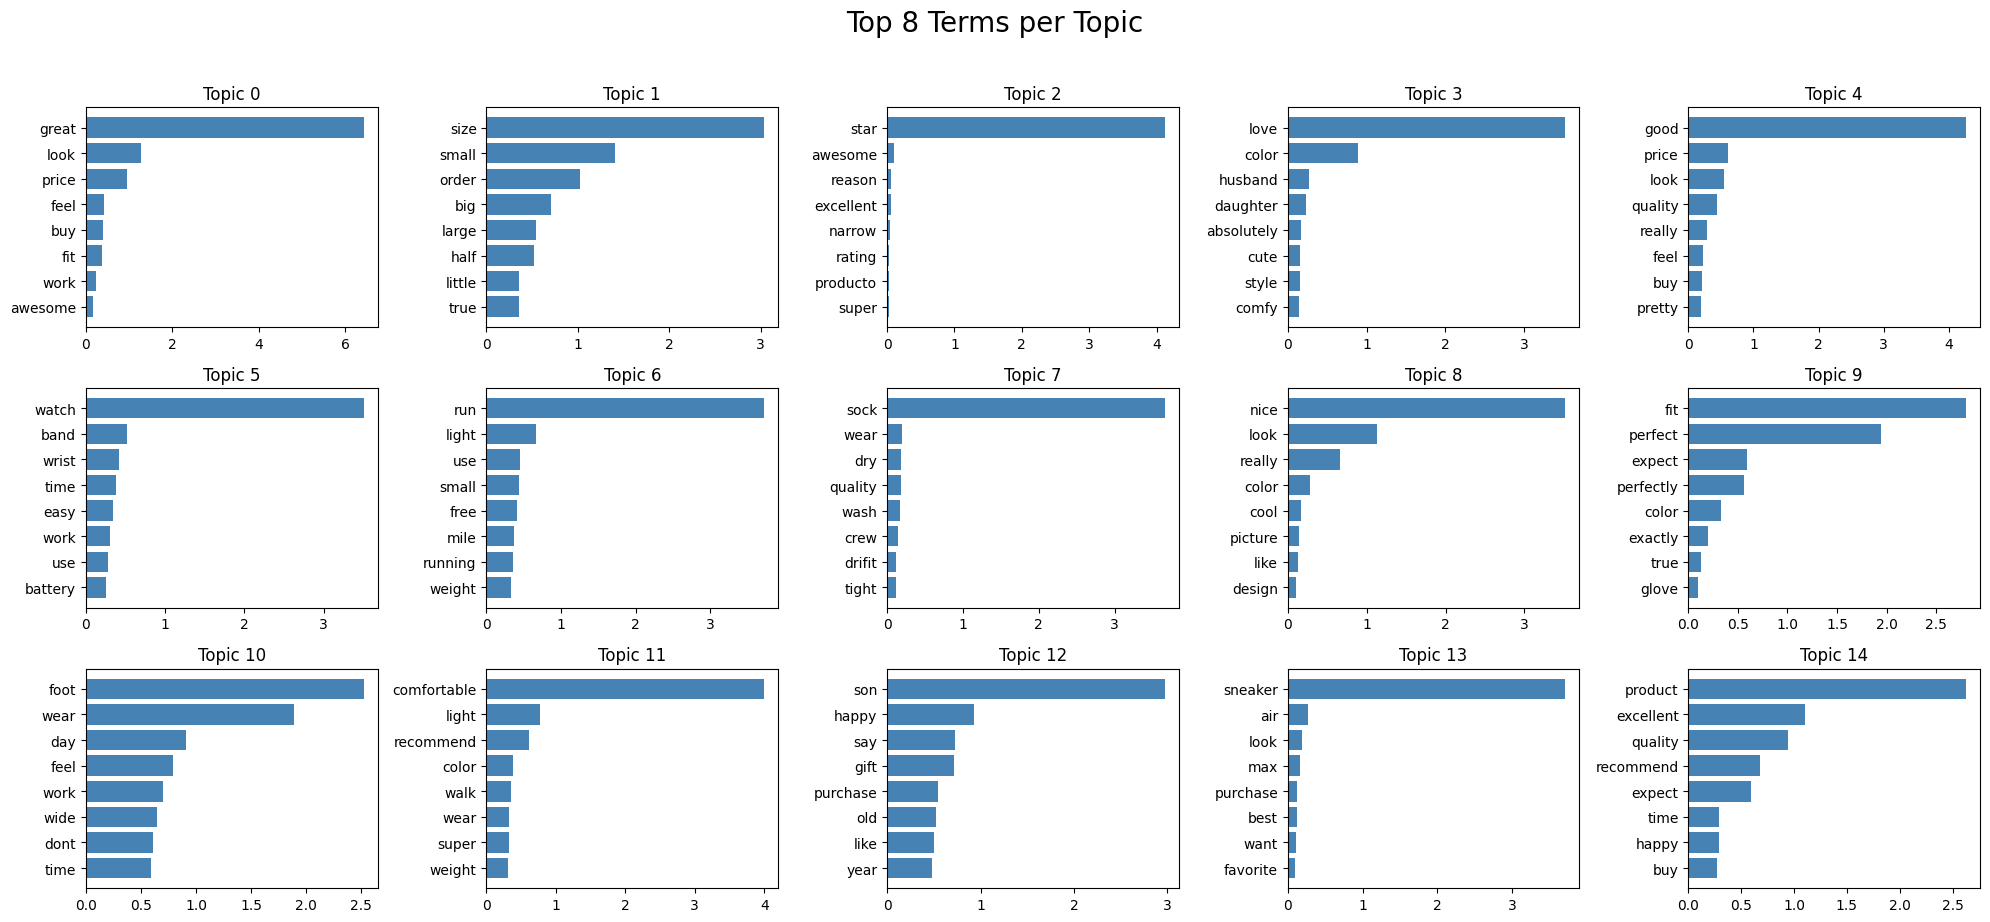

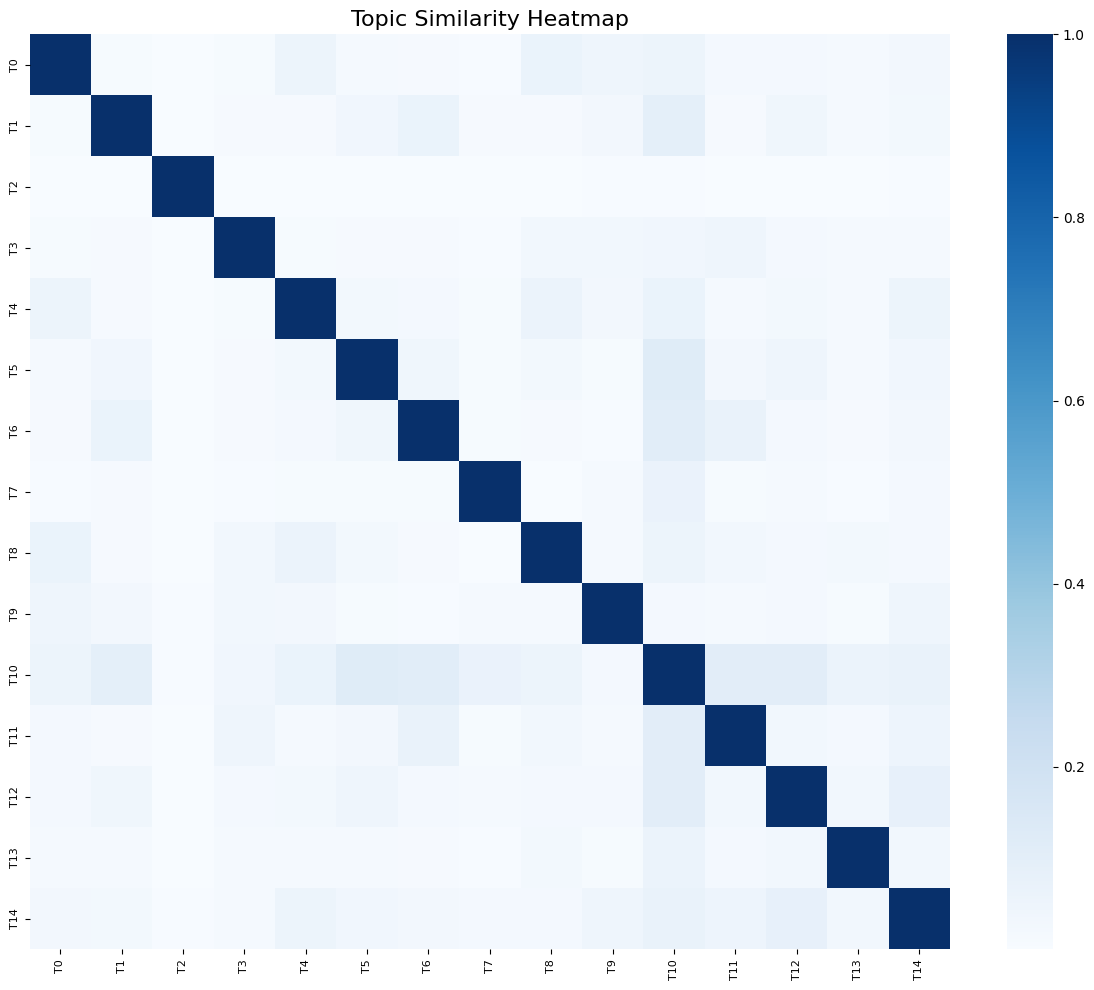

In [9]:
df_reviews['dominant_topic2'] = np.argmax(doc_topic_matrix2, axis=1)

# Extract the topic-term matrix
topic_term_matrix2 = nmf_model2.components_
feature_names2 = tfidf_vect.get_feature_names_out()

topic_counts2 = df_reviews['dominant_topic2'].value_counts()
topic_sizes2 = np.array([topic_counts2.get(i, 0) for i in range(NUM_TOPICS)])

#Distant map
plt.figure(figsize=(12, 9))
distances = cosine_distances(topic_term_matrix2)
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
topic_coordinates = mds.fit_transform(distances)

plt.scatter(topic_coordinates[:, 0], topic_coordinates[:, 1],
            s=topic_sizes2 * 0.5, alpha=0.6, c=range(NUM_TOPICS), cmap='viridis')

for i in range(NUM_TOPICS):
    plt.annotate(f'{i}', (topic_coordinates[i, 0], topic_coordinates[i, 1]),
                 fontsize=9, fontweight='bold', ha='center')

plt.title(f'Intertopic Distance Map ({NUM_TOPICS} Topics)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

#Dendogram
plt.figure(figsize=(14, 6))
Z = linkage(topic_term_matrix2, method='ward')

dendrogram(Z, labels=[f'T{i}' for i in range(NUM_TOPICS)],
           leaf_rotation=90, leaf_font_size=10)

plt.title('Hierarchical Clustering of Topics', fontsize=16)
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


#Dynamic Grid
n_top_words = 8
cols = 5
rows = math.ceil(NUM_TOPICS / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 3 * rows))
axes = axes.flatten()

for topic_idx, topic in enumerate(topic_term_matrix2):
    top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
    top_features = [feature_names2[i] for i in top_features_ind]
    weights = topic[top_features_ind]

    ax = axes[topic_idx]
    ax.barh(top_features, weights, color='steelblue')
    ax.set_title(f'Topic {topic_idx}', fontdict={'fontsize': 12})
    ax.invert_yaxis()

for i in range(NUM_TOPICS, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(f'Top {n_top_words} Terms per Topic', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

#Heatmap (using Cosin Similarity)
plt.figure(figsize=(12, 10))
similarity_matrix2 = cosine_similarity(topic_term_matrix2)

sns.heatmap(similarity_matrix2,
            annot=False,
            cmap='Blues',
            xticklabels=[f'T{i}' for i in range(NUM_TOPICS)],
            yticklabels=[f'T{i}' for i in range(NUM_TOPICS)])

plt.title('Topic Similarity Heatmap', fontsize=16)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [10]:
print((topic_counts2 / topic_counts2.sum() * 100).round(1).sort_values(ascending=False))

dominant_topic2
10    12.4
3     10.6
1     10.0
9      7.6
12     7.1
6      6.8
14     6.7
8      6.4
4      6.4
11     6.1
5      5.0
13     4.3
0      3.9
7      3.6
2      3.0
Name: count, dtype: float64


we can observe in the bubble chart that topic 6 contains most of reviews while topic 2 contains smallest number of review - which then confirm on the dominant_topic2 distribution above. Also both bubble chart and dendogram suggest now the topics are better identical to each other - which means we can analyse info within 1 topic with less concern of potential overlapping of that review in other topic.

## 5. Topic Classification

### Checking category-level comments about size, tightness, and discomfort to identify products that may need improvement

In [11]:
#Classify each review as Positive (rating > 4) or Non-Positive (rating <= 4)
df_reviews['rating_class'] = np.where(df_reviews['overall'] > 4, 'Positive', 'Non-Positive')

#check Positive vs non-Positive breakdown across all topics
topic_class_counts = df_reviews.groupby(['dominant_topic2', 'rating_class']).size().unstack(fill_value=0)
topic_class_counts['total'] = topic_class_counts.sum(axis=1)
topic_class_counts['non_positive_pct'] = (topic_class_counts.get('Non-Positive', 0) / topic_class_counts['total'] * 100).round(2)
topic_class_counts = topic_class_counts.sort_values(by='non_positive_pct', ascending=False)

print('Positive vs Non-Positive share by topic (highest concern first):')
print(topic_class_counts.to_string())

# Check reviews in dominant topic as 1 (sizing-related)
topic1_reviews = df_reviews[df_reviews['dominant_topic2'] == 1]

topic1_by_product = topic1_reviews.groupby(['asin', 'product_title']).agg(
    review_count=('reviewText', 'count'),
    avg_rating=('overall', 'mean'),
    non_positive_count=('rating_class', lambda x: (x == 'Non-Positive').sum())
).reset_index()
topic1_by_product['non_positive_pct'] = (topic1_by_product['non_positive_count'] / topic1_by_product['review_count'] * 100).round(2)

#check rating average with at least 5 reviews available to avoid skew/bias on 1 2 negative review in total 4 reviews only
MIN_REVIEWS = 5
worst_rated = topic1_by_product[topic1_by_product['review_count'] >= MIN_REVIEWS].sort_values(by='avg_rating', ascending=True)

print(f'\nProducts with lowest avg rating in Topic 1 (min {MIN_REVIEWS} reviews):')
print(worst_rated.head(15).to_string(index=False))

# Combined concern score
topic1_by_product['volume_norm'] = (topic1_by_product['review_count'] - topic1_by_product['review_count'].min()) / \
    (topic1_by_product['review_count'].max() - topic1_by_product['review_count'].min())
topic1_by_product['rating_norm_inv'] = 1 - (topic1_by_product['avg_rating'] - topic1_by_product['avg_rating'].min()) / \
    (topic1_by_product['avg_rating'].max() - topic1_by_product['avg_rating'].min())
topic1_by_product['concern_score'] = (topic1_by_product['volume_norm'] + topic1_by_product['rating_norm_inv']) / 2

top_concern = topic1_by_product[topic1_by_product['review_count'] >= MIN_REVIEWS].sort_values(by='concern_score', ascending=False)

print(f'\nTop products by combined concern score (high volume + low rating):')
print(top_concern[['asin', 'product_title', 'review_count', 'avg_rating', 'non_positive_pct', 'concern_score']].head(15).to_string(index=False))

#Sample reviews for the top combined-concern product
top_asin = top_concern.iloc[0]['asin']
print(f"\n=== Sample reviews for top concern product ({top_asin}) ===")
for _, row in topic1_reviews[topic1_reviews['asin'] == top_asin].head(10).iterrows():
    print(f"Rating: {row['overall']} ({row['rating_class']}) | Review: {row['reviewText']}\n{'-'*80}")

Positive vs Non-Positive share by topic (highest concern first):
rating_class     Non-Positive  Positive  total  non_positive_pct
dominant_topic2                                                 
1                        1281       877   2158             59.36
5                         625       456   1081             57.82
10                       1282      1398   2680             47.84
4                         635       745   1380             46.01
7                         311       463    774             40.18
8                         548       843   1391             39.40
2                         239       415    654             36.54
6                         514       943   1457             35.28
14                        497       943   1440             34.51
13                        268       663    931             28.79
12                        380      1152   1532             24.80
9                         400      1246   1646             24.30
11                       

here we see size concern concentrates on the footwear segment (sneakers, hiking shoes, boots, etc.). Let's check what share of reviews in this segment complain about size, along with the average rating.

In [12]:
import scipy.stats as stats
# Now let's check average rating per topic (0-9), sorted worst first
topic_rating_summary = df_reviews.groupby('dominant_topic2').agg(
    review_count=('overall', 'count'),
    avg_rating=('overall', 'mean')).reset_index().sort_values(by='avg_rating')

overall_avg_rating = df_reviews['overall'].mean()
topic_rating_summary['diff_from_overall'] = (topic_rating_summary['avg_rating'] - overall_avg_rating).round(3)

print(f'Overall average rating (all reviews): {overall_avg_rating:.3f}\n')
print('Average rating by topic (lowest first):')
print(topic_rating_summary.to_string(index=False))

if 'category_list' not in df_reviews.columns:
    df_reviews['category_list'] = df_reviews['asin'].map(nike_asin_to_categories)

#define footwear pattern
footwear_pattern = 'shoe|sneaker|boot|cleat|footwear'

# Re-explode categories now that dominant_topic2 exists, and tag Footwear vs everything else
df_exploded2 = df_reviews.explode('category_list')
df_exploded2['segment'] = np.where(
    df_exploded2['category_list'].astype(str).str.contains(footwear_pattern, case=False, na=False), 'Footwear', 'Apparel/Other')

# Average rating by Segment x Topic, to see whether sizing hits footwear specifically
segment_topic_rating = df_exploded2.groupby(['segment', 'dominant_topic2']).agg(
    review_count=('overall', 'count'),
    avg_rating=('overall', 'mean')).reset_index()

pivot = segment_topic_rating.pivot(index='dominant_topic2', columns='segment', values='avg_rating').round(2)
print('\nAverage rating by Topic x Segment:')
print(pivot.to_string())

# Confirm Topic 1's actual composition
topic1_segment_counts = df_exploded2[df_exploded2['dominant_topic2'] == 1]['segment'].value_counts()
print('\nTopic 1 composition by segment:')
print(topic1_segment_counts)
print((topic1_segment_counts / topic1_segment_counts.sum() * 100).round(1).astype(str) + '%')

# Statistical test: is Topic 1's rating meaningfully lower than everything else?
topic1_ratings = df_reviews.loc[df_reviews['dominant_topic2'] == 1, 'overall'].dropna()
other_ratings = df_reviews.loc[df_reviews['dominant_topic2'] != 1, 'overall'].dropna()
t_stat, p_val = stats.ttest_ind(topic1_ratings, other_ratings, equal_var=False)

print(f'\nTopic 1 (sizing) avg rating: {topic1_ratings.mean():.3f} (n={len(topic1_ratings)})')
print(f'All other topics avg rating: {other_ratings.mean():.3f} (n={len(other_ratings)})')
print(f'Difference: {topic1_ratings.mean() - other_ratings.mean():.3f}')
print(f'T-test p-value: {p_val:.5f}')

Overall average rating (all reviews): 4.296

Average rating by topic (lowest first):
 dominant_topic2  review_count  avg_rating  diff_from_overall
               1          2158    3.723818             -0.572
               5          1081    3.740056             -0.556
              10          2680    3.872761             -0.423
              14          1440    4.177083             -0.119
               7           774    4.222222             -0.074
               4          1380    4.260870             -0.035
               6          1457    4.358957              0.063
               8          1391    4.376707              0.081
               2           654    4.408257              0.112
              13           931    4.419979              0.124
              12          1532    4.550914              0.255
               9          1646    4.601458              0.305
              11          1322    4.647504              0.351
               0           841    4.752675     

Statistically significant (p≈0.00000, huge sample size) and practically meaningful (-0.64 points is ~15% reduction, it's noticeable gap).
 Topic 1 was built from words like "size/small/large," so it's not that being in this topic causes the lower rating — it's that sizing complaints and lower ratings are two symptoms of the same fit problem.
Reviews centered on sizing/fit complaints carry a ~0.7-point rating penalty vs. the rest of the catalog — a significant and meaningful gap, concentrated mainly in footwear.

## 6. Analysis & Actionable Business Insights

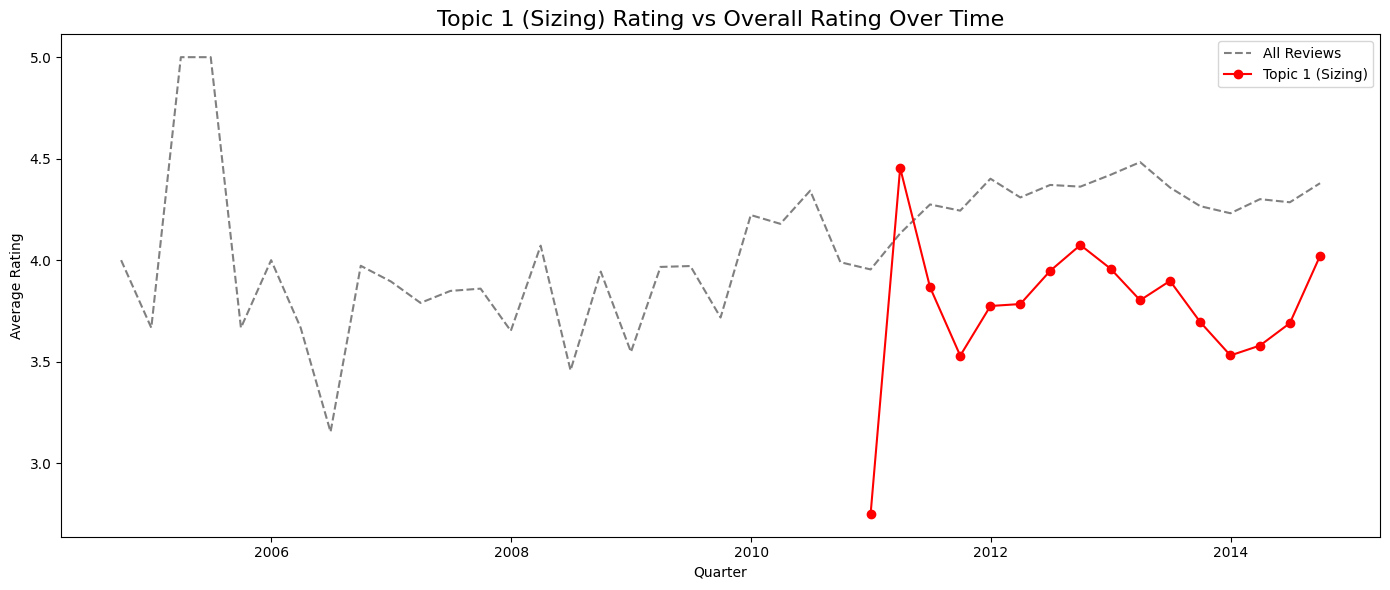

In [13]:
if 'date' not in df_reviews.columns:
    df_reviews['date'] = pd.to_datetime(df_reviews['unixReviewTime'], unit='s', errors='coerce')

#Average rating per topic by quarter
topic_time_trend = df_reviews.dropna(subset=['date']).set_index('date').groupby('dominant_topic2').resample('QE').agg(
    avg_rating=('overall', 'mean'),
    review_count=('overall', 'count')
).reset_index()
topic_time_trend = topic_time_trend[topic_time_trend['review_count'] > 5]

# Isolate Topic 1 (sizing) against the overall trend to see if the gap is widening/stable/narrowing
overall_trend = df_reviews.dropna(subset=['date']).set_index('date').resample('QE')['overall'].mean()
topic1_trend = topic_time_trend[topic_time_trend['dominant_topic2'] == 1].set_index('date')['avg_rating']

plt.figure(figsize=(14, 6))
plt.plot(overall_trend.index, overall_trend.values, label='All Reviews', color='gray', linestyle='--')
plt.plot(topic1_trend.index, topic1_trend.values, label='Topic 1 (Sizing)', color='red', marker='o')
plt.title('Topic 1 (Sizing) Rating vs Overall Rating Over Time', fontsize=16)
plt.xlabel('Quarter')
plt.ylabel('Average Rating')
plt.legend()
plt.tight_layout()
plt.show()

## III. CONCLUSION


**Recommendation: Address Persistent Sizing/Fit Issues in Footwear**

**The evidence**
Reviews centered on sizing/fit (Topic 1) rate 0.7 points lower than the rest of the catalog (3.7 vs 4.4) — statistically significant (p<0.001) and a meaningful ~15% gap on the scale.
The problem is concentrated in footwear, not apparel broadly.
The gap has persisted since 2011 even as overall ratings climbed toward 4.3-4.5 in 2012-2013. Sizing complaints simply didn't improve alongside everything else.
Worst-offending products (low rating + high volume) include the Nike Men's Benassi Swoosh Slide Sandal (94 reviews, 2.99 avg), Air Monarch IV Cross Training (26 reviews, 3.0 avg), and Nike Free 5.0+ Running Shoes (44 reviews, 3.82 avg) — repeat offenders worth prioritizing first.

**Recommended actions**

    i) Audit sizing/last specs on the Benassi Slide, Air Monarch IV, and Free 5.0+ lines specifically. Also consider to add a size-fit guidance callout ("runs small/narrow") on Product Page for footwear with repeated sizing complaints — a cheap, fast fix that reduces returns before any redesign ships.
    
    ii) Introduce wider sizing variants for narrow-fit lines like Air Max and VaporMax — directly targets the most-cited complaint pattern.
    
    iii) Re-assessing this topic/rating analysis quarterly to confirm whether interventions actually close the gap, since it hasn't closed on its own in 4+ years.

**Future works**
Using topic model result to analyze also other segment/topic to identify what makes user love the most to invest more on that area.
Try BERTopic model to see if the group is more coherent.